In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
train_df = pd.read_csv("Datast/train.csv")
test_df = pd.read_csv("Datast/test.csv")
building_df = pd.read_csv("Datast/building_metadata.csv")
weather_train_df = pd.read_csv("Datast/weather_train.csv")
weather_test_df = pd.read_csv("Datast/weather_test.csv")

In [3]:
train_df.head()

,building_id,meter,timestamp,meter_reading
0,0,0,2016-01-01 00:00:00,0.0
1,1,0,2016-01-01 00:00:00,0.0
2,2,0,2016-01-01 00:00:00,0.0
3,3,0,2016-01-01 00:00:00,0.0
4,4,0,2016-01-01 00:00:00,0.0


In [4]:
train_df.columns

Index(['building_id', 'meter', 'timestamp', 'meter_reading'], dtype='object')

In [5]:
building_df.columns

Index(['site_id', 'building_id', 'primary_use', 'square_feet', 'year_built',
       'floor_count'],
      dtype='object')

In [6]:
weather_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139773 entries, 0 to 139772
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   site_id             139773 non-null  int64  
 1   timestamp           139773 non-null  object 
 2   air_temperature     139718 non-null  float64
 3   cloud_coverage      70600 non-null   float64
 4   dew_temperature     139660 non-null  float64
 5   precip_depth_1_hr   89484 non-null   float64
 6   sea_level_pressure  129155 non-null  float64
 7   wind_direction      133505 non-null  float64
 8   wind_speed          139469 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 9.6+ MB


In [7]:
print("train_df_shape ",train_df.shape)
print("building_df_shape",building_df.shape)
print("weather_train_df_shape",weather_train_df.shape)

train_df_shape  (20216100, 4)
building_df_shape (1449, 6)
weather_train_df_shape (139773, 9)


In [8]:
train_df.isnull().sum()
# building_df.isnull().sum()
# weather_train_df.isnull().sum()

building_id      0
meter            0
timestamp        0
meter_reading    0
dtype: int64

In [9]:
train_merged = train_df.merge(building_df, on="building_id", how="inner")
main_merged = train_merged.merge(weather_train_df, on=["site_id", "timestamp"], how="inner")
main_merged.columns

Index(['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id',
       'primary_use', 'square_feet', 'year_built', 'floor_count',
       'air_temperature', 'cloud_coverage', 'dew_temperature',
       'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction',
       'wind_speed'],
      dtype='object')

In [ ]:
sample = main_merged.sample(n=100000)

In [ ]:


profile = sample.profile_report(title='Pandas Profiling Report', check_correlation_pearson=False,
correlations={'pearson': False,
'spearman': False,
'kendall': False,
'phi_k': False,
'cramers': False,
'recoded': False})
profile.to_file(output_file="output.html")



In [10]:
# main_merged.head()
# train_merged.head()
# train_merged.isnull().sum()
main_merged.shape

(20125605, 16)

In [11]:
# main_merged.isnull().sum()
# main_merged.info()
main_merged.describe()
main_merged.head()

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,2016-01-01 00:00:00,0.0,0,Education,7432,2008.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,1,0,2016-01-01 00:00:00,0.0,0,Education,2720,2004.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
2,2,0,2016-01-01 00:00:00,0.0,0,Education,5376,1991.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
3,3,0,2016-01-01 00:00:00,0.0,0,Education,23685,2002.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
4,4,0,2016-01-01 00:00:00,0.0,0,Education,116607,1975.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0


In [12]:
main_merged.isnull().sum()

building_id                  0
meter                        0
timestamp                    0
meter_reading                0
site_id                      0
primary_use                  0
square_feet                  0
year_built            12113306
floor_count           16630052
air_temperature           6163
cloud_coverage         8734870
dew_temperature           9645
precip_depth_1_hr      3658528
sea_level_pressure     1141174
wind_direction         1358553
wind_speed               53181
dtype: int64

In [13]:
main_merged.duplicated().sum()

np.int64(0)

In [14]:
missing_percentage = main_merged.isnull().sum() / len(main_merged) * 100
print(missing_percentage.sort_values(ascending=False))
cp_main=main_merged.copy()

floor_count           82.631315
year_built            60.188531
cloud_coverage        43.401776
precip_depth_1_hr     18.178475
wind_direction         6.750371
sea_level_pressure     5.670259
wind_speed             0.264245
dew_temperature        0.047924
air_temperature        0.030623
square_feet            0.000000
site_id                0.000000
primary_use            0.000000
meter                  0.000000
timestamp              0.000000
building_id            0.000000
meter_reading          0.000000
dtype: float64


floor_count           82.631315
year_built            60.188531
cloud_coverage        43.401776
precip_depth_1_hr     18.178475
wind_direction         6.750371
sea_level_pressure     5.670259
wind_speed             0.264245
dew_temperature        0.047924
air_temperature        0.030623
square_feet            0.000000
site_id                0.000000
primary_use            0.000000
meter                  0.000000
timestamp              0.000000
building_id            0.000000
meter_reading          0.000000
dtype: float64


array([[<Axes: title={'center': 'building_id'}>,
        <Axes: title={'center': 'meter'}>,
        <Axes: title={'center': 'meter_reading'}>,
        <Axes: title={'center': 'site_id'}>],
       [<Axes: title={'center': 'square_feet'}>,
        <Axes: title={'center': 'year_built'}>,
        <Axes: title={'center': 'floor_count'}>,
        <Axes: title={'center': 'air_temperature'}>],
       [<Axes: title={'center': 'cloud_coverage'}>,
        <Axes: title={'center': 'dew_temperature'}>,
        <Axes: title={'center': 'precip_depth_1_hr'}>,
        <Axes: title={'center': 'sea_level_pressure'}>],
       [<Axes: title={'center': 'wind_direction'}>,
        <Axes: title={'center': 'wind_speed'}>, <Axes: >, <Axes: >]],
      dtype=object)

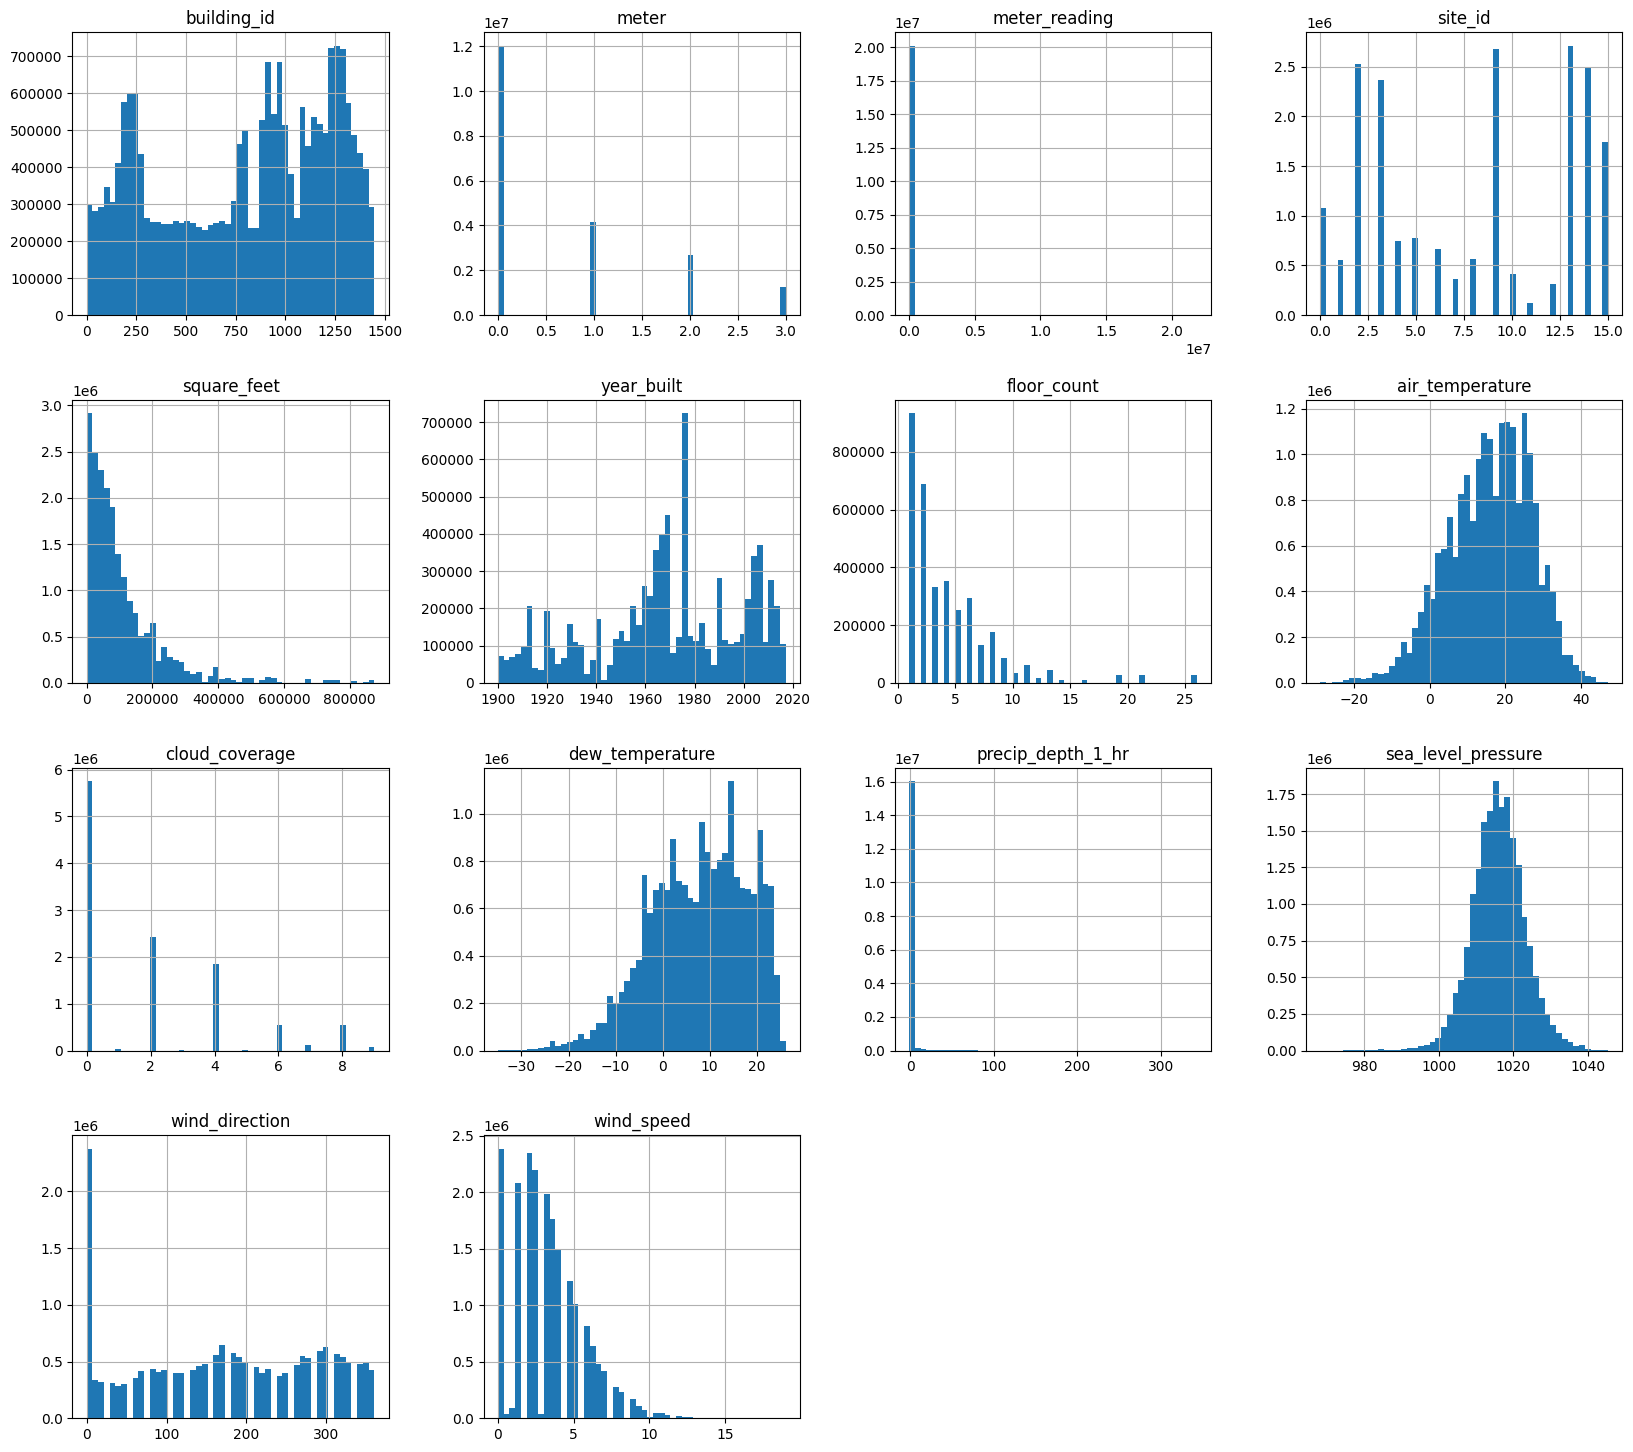

In [15]:
missing_percentage = cp_main.isnull().sum() / len(cp_main) * 100
print(missing_percentage.sort_values(ascending=False))
cp_main.hist(bins=50,figsize=(20,18))

In [16]:
cp_main.drop(columns=['year_built'],inplace=True)

floor_count           82.631315
cloud_coverage        43.401776
precip_depth_1_hr     18.178475
wind_direction         6.750371
sea_level_pressure     5.670259
wind_speed             0.264245
dew_temperature        0.047924
air_temperature        0.030623
square_feet            0.000000
site_id                0.000000
primary_use            0.000000
timestamp              0.000000
meter                  0.000000
building_id            0.000000
meter_reading          0.000000
dtype: float64


array([[<Axes: title={'center': 'building_id'}>,
        <Axes: title={'center': 'meter'}>,
        <Axes: title={'center': 'meter_reading'}>,
        <Axes: title={'center': 'site_id'}>],
       [<Axes: title={'center': 'square_feet'}>,
        <Axes: title={'center': 'floor_count'}>,
        <Axes: title={'center': 'air_temperature'}>,
        <Axes: title={'center': 'cloud_coverage'}>],
       [<Axes: title={'center': 'dew_temperature'}>,
        <Axes: title={'center': 'precip_depth_1_hr'}>,
        <Axes: title={'center': 'sea_level_pressure'}>,
        <Axes: title={'center': 'wind_direction'}>],
       [<Axes: title={'center': 'wind_speed'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

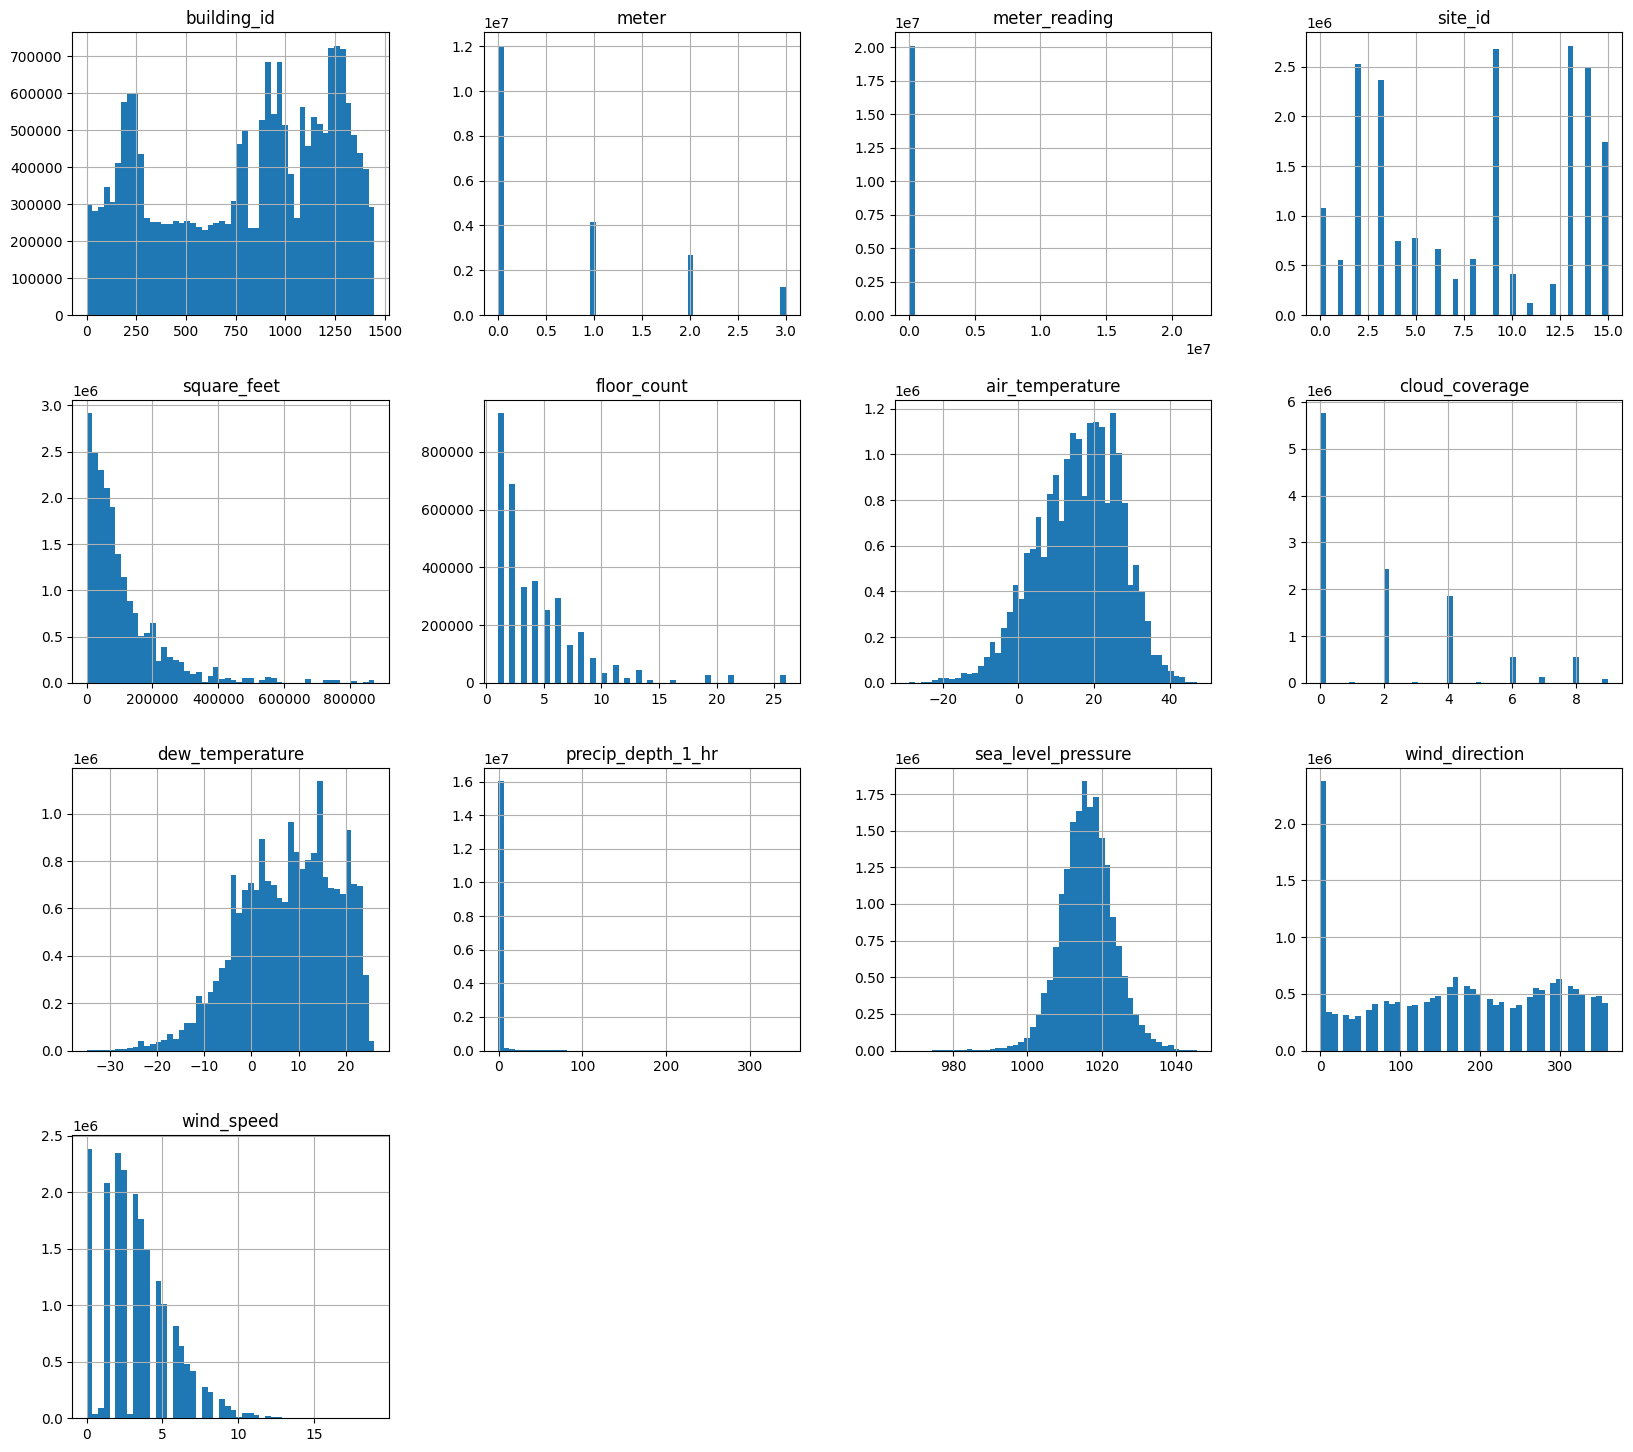

In [17]:
missing_percentage = cp_main.isnull().sum() / len(cp_main) * 100
print(missing_percentage.sort_values(ascending=False))
cp_main.hist(bins=50,figsize=(20,18))

In [24]:
new=cp_main['cloud_coverage'].sum()*.95
print(new)

20564852.349999998


In [25]:
cp_main['cloud_coverage']=cp_main['cloud_coverage']<20564852.349999998

In [73]:
Q1 = cp_main['cloud_coverage'].quantile(0.25)
Q3 = cp_main['cloud_coverage'].quantile(0.75)
IQR = Q3 - Q1

df_cleaned = cp_main[(cp_main['cloud_coverage'] >= Q1 - 1.5 * IQR) & (cp_main['cloud_coverage'] <= Q3 + 1.5 * IQR)]
print(df_cleaned)

          building_id  meter            timestamp  meter_reading  site_id  \
103               105      0  2016-01-01 00:00:00        23.3036        1   
104               106      0  2016-01-01 00:00:00         0.3746        1   
105               106      3  2016-01-01 00:00:00         0.0000        1   
106               107      0  2016-01-01 00:00:00       175.1840        1   
107               108      0  2016-01-01 00:00:00        91.2653        1   
...               ...    ...                  ...            ...      ...   
20125600         1444      0  2016-12-31 23:00:00         8.7500       15   
20125601         1445      0  2016-12-31 23:00:00         4.8250       15   
20125602         1446      0  2016-12-31 23:00:00         0.0000       15   
20125603         1447      0  2016-12-31 23:00:00       159.5750       15   
20125604         1448      0  2016-12-31 23:00:00         2.8500       15   

                            primary_use  square_feet  floor_count  \
103   

In [31]:
cp_main.isnull().sum()

building_id                  0
meter                        0
timestamp                    0
meter_reading                0
site_id                      0
primary_use                  0
square_feet                  0
floor_count           16630052
air_temperature           6163
cloud_coverage               0
dew_temperature           9645
precip_depth_1_hr            0
sea_level_pressure     1141174
wind_direction         1358553
wind_speed               53181
dtype: int64

<Axes: >

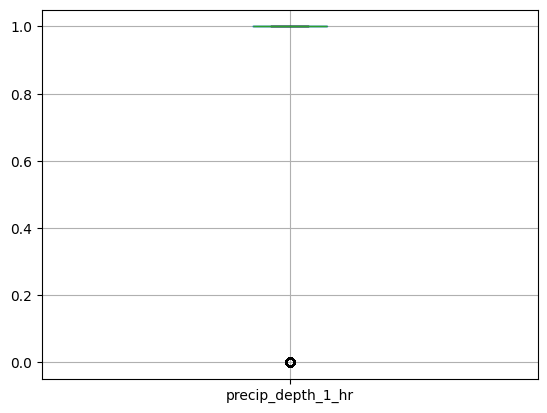

In [30]:
cp_main.boxplot(column=['precip_depth_1_hr'])

In [29]:
cp_main['precip_depth_1_hr']=cp_main['precip_depth_1_hr']<20564852.349999998

floor_count           82.631315
year_built            60.188531
precip_depth_1_hr     18.178475
wind_direction         6.750371
sea_level_pressure     5.670259
wind_speed             0.264245
dew_temperature        0.047924
air_temperature        0.030623
square_feet            0.000000
primary_use            0.000000
site_id                0.000000
meter_reading          0.000000
meter                  0.000000
timestamp              0.000000
building_id            0.000000
cloud_coverage         0.000000
dtype: float64


array([[<Axes: title={'center': 'building_id'}>,
        <Axes: title={'center': 'meter'}>,
        <Axes: title={'center': 'meter_reading'}>,
        <Axes: title={'center': 'site_id'}>],
       [<Axes: title={'center': 'square_feet'}>,
        <Axes: title={'center': 'year_built'}>,
        <Axes: title={'center': 'floor_count'}>,
        <Axes: title={'center': 'air_temperature'}>],
       [<Axes: title={'center': 'cloud_coverage'}>,
        <Axes: title={'center': 'dew_temperature'}>,
        <Axes: title={'center': 'precip_depth_1_hr'}>,
        <Axes: title={'center': 'sea_level_pressure'}>],
       [<Axes: title={'center': 'wind_direction'}>,
        <Axes: title={'center': 'wind_speed'}>, <Axes: >, <Axes: >]],
      dtype=object)

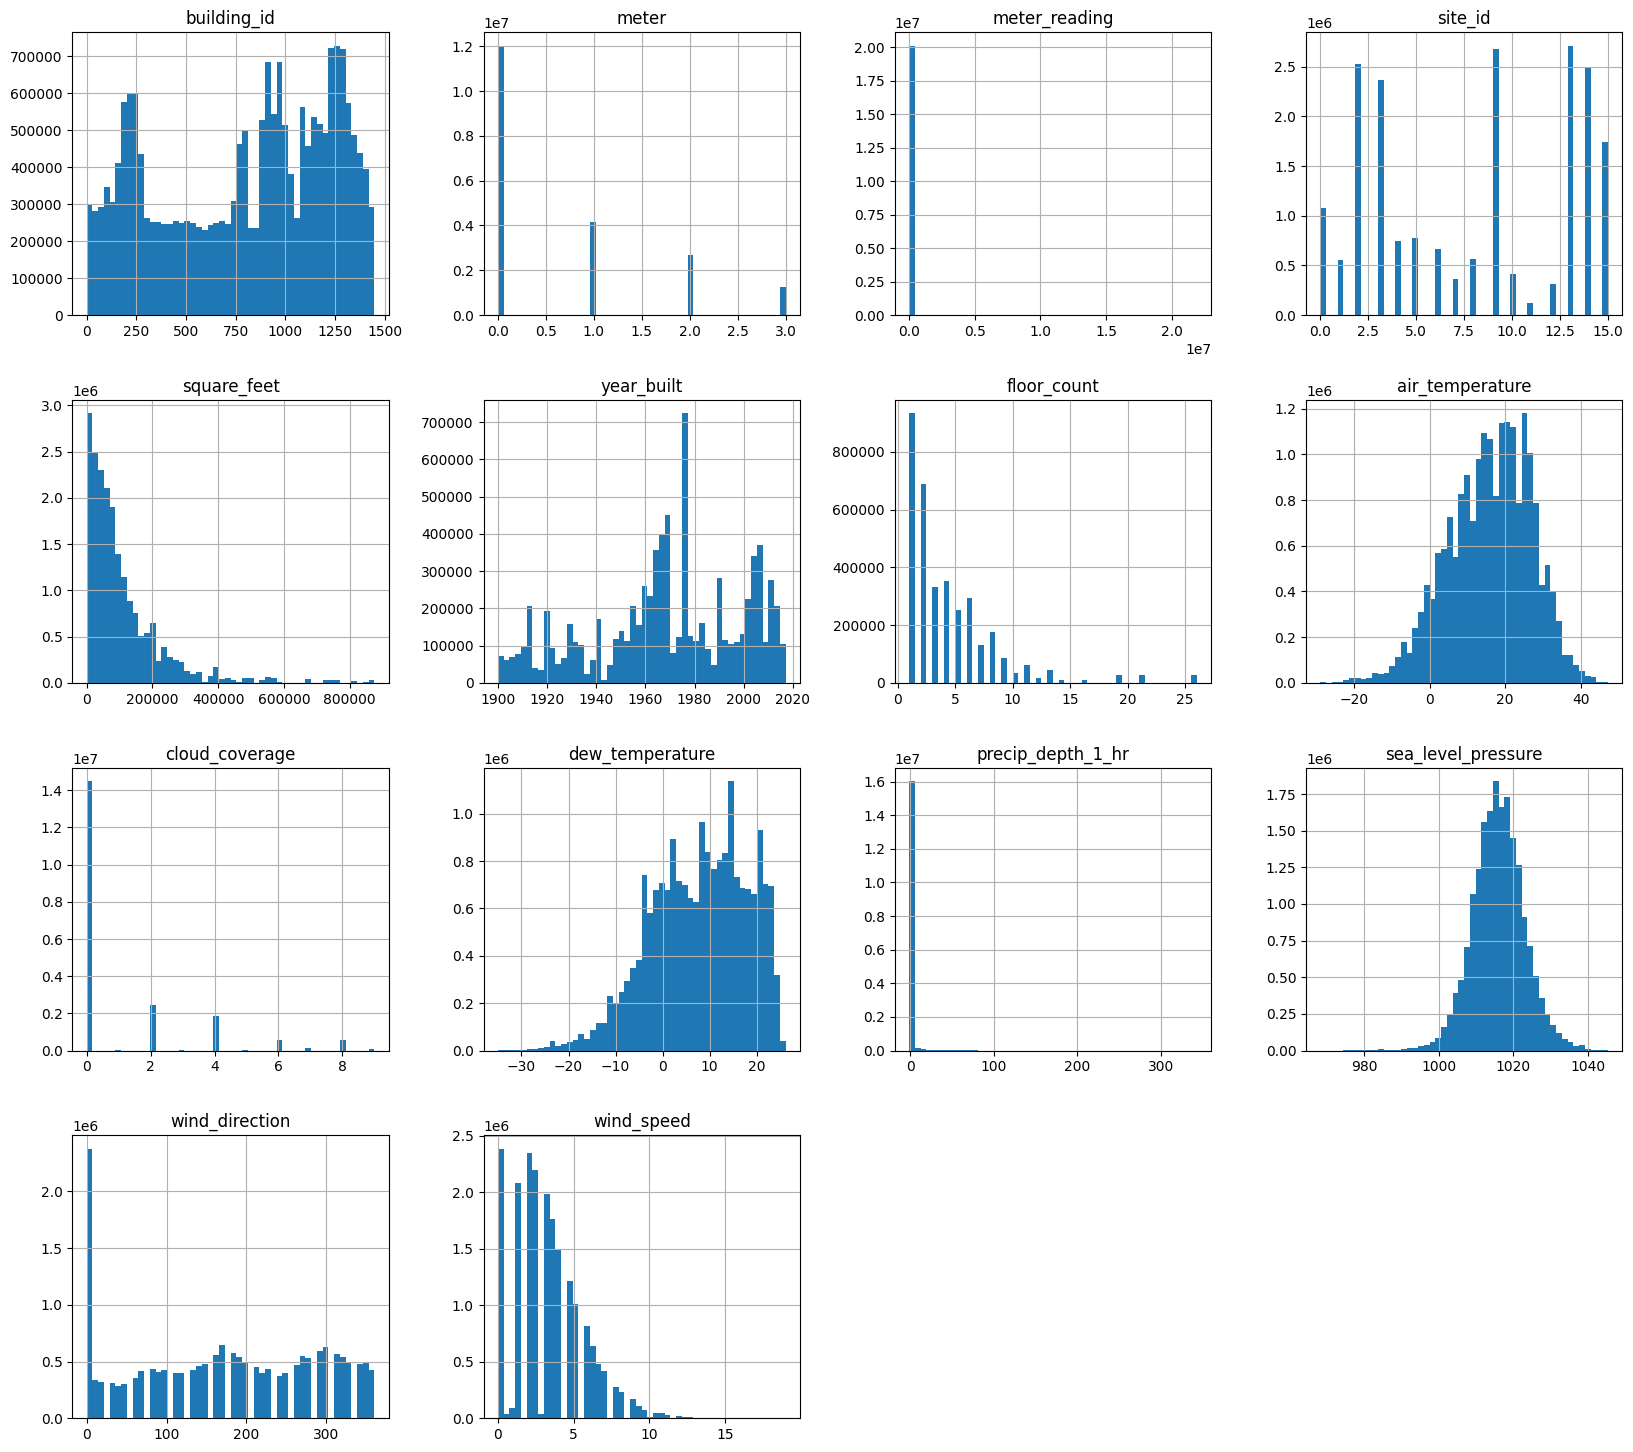

In [62]:
missing_percentage = cp_main.isnull().sum() / len(cp_main) * 100
print(missing_percentage.sort_values(ascending=False))
cp_main.hist(bins=50,figsize=(20,18))

In [24]:

# plt.figure(figsize=(12,6))
# sns.heatmap(main_merged.isnull(), cmap='viridis', cbar=False, yticklabels=False)
# plt.title("Missing Values Heatmap")
# plt.show()

In [84]:
# plt.figure(figsize=(10,5))
# sns.histplot(train_df['meter_reading'],bins=50)
# plt.title("Meter Reading Distribution")
# plt.show()

In [25]:
train_df['meter_reading'].value_counts()

meter_reading
0.0000      1873976
20.0000       23363
2.9307        23181
36.6000       22154
8.7921        21787
             ...   
884.0020          1
9.1303            1
9.4152            1
925.2090          1
870.8210          1
Name: count, Length: 1688175, dtype: int64

In [ ]:
# x=main_merged[main_merged["site_id"]==0]
# x["meter"].value_counts()

meter
0    908409
1    168253
Name: count, dtype: int64

In [74]:
main_merged['meter'].value_counts()

meter
0    12060910
1     4182440
2     2708713
3     1264037
Name: count, dtype: int64

In [75]:
build0=main_merged[main_merged['building_id']==0]
build0['meter'].value_counts()

meter
0    8784
Name: count, dtype: int64